# CRMLS Exploratory Data Analysis

## SCAN Framework

**Stakeholder Goal:** Understand California single-family home sales and identify the major factors and data issues relevant to predicting `ClosePrice`.

This notebook explores CRMLS sold-property data before preprocessing and modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Inspection

First, load one month of CRMLS data to inspect the dataset structure and available columns.

In [6]:
df_test = pd.read_csv("../data/raw/CRMLSSold202601.csv")

df_test.head()

/var/folders/p3/xl30ms2s591gsby90l48lf4r0000gn/T/ipykernel_7624/2028755234.py:1: DtypeWarning: Columns (4: WaterfrontYN, 74: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv("../data/raw/CRMLSSold202601.csv")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,Mlslistings,Mlslistings,"Tile,Wood",True,NaN,NaN,NaN,NaN,1151961326,billy@mcnairgroup.com,...,NaN,51219.0,NaN,False,2.0,Other,94062,NaN,51219.0,NaN
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Tile,Vinyl,Wood",True,NaN,NaN,False,4000.0,1151961163,realtorjasonp@gmail.com,...,NaN,13496.0,NaN,False,2.0,NaN,90004,NaN,13496.0,NaN
2,Delta,Delta,Laminate,NaN,NaN,NaN,False,2975000.0,1151959385,LoriAbreu10@gmail.com,...,NaN,238186.0,NaN,False,0.0,NaN,94517,NaN,238186.0,NaN
3,SouthBay,SouthBay,"Tile,Wood",False,NaN,NaN,False,1340000.0,1151952151,jen@jencaskeygroup.com,...,NaN,4970.0,0.0,False,2.0,Redondo Unified,90278,0.0,4970.0,NaN
4,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,720000.0,1151944067,aaronguzmanre@gmail.com,...,NaN,8224.0,2.0,False,2.0,El Monte Union High,91770,0.0,8224.0,NaN


In [4]:
print("Rows:", df_test.shape[0])
print("Columns:", df_test.shape[1])

df_test.columns.tolist()

Rows: 16487
Columns: 78


['BuyerAgentAOR',
 'ListAgentAOR',
 'Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'TaxYear',
 'BuildingAreaTotal',
 'BedroomsTota

In [5]:
key_columns = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet',
    'PropertyType',
    'PropertySubType'
]

df_test[key_columns].head(10)

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,PropertyType,PropertySubType
0,11706000.0,4636.0,4.0,6.0,51219.0,Residential,SingleFamilyResidence
1,4000.0,1250.0,3.0,2.0,13496.0,ResidentialLease,Condominium
2,2975000.0,1600.0,2.0,1.0,238186.0,Residential,SingleFamilyResidence
3,1340000.0,1702.0,3.0,2.0,4970.0,Residential,Townhouse
4,720000.0,937.0,2.0,1.0,8224.0,Residential,SingleFamilyResidence
5,600000.0,1267.0,3.0,1.0,6716.0,Residential,SingleFamilyResidence
6,850000.0,NaN,NaN,NaN,5663.0,ResidentialIncome,Duplex
7,1750000.0,1637.0,3.0,3.0,NaN,Residential,Townhouse
8,15991988.0,1920.0,4.0,4.0,3670.0,Residential,SingleFamilyResidence
9,3636725.0,3185.0,4.0,4.0,8750.0,Residential,SingleFamilyResidence


## 2. Multi-Month Data Preparation

Load the CRMLS monthly sold-property datasets, combine them into a single DataFrame, and restrict the analysis to residential single-family homes.

In [14]:
from pathlib import Path

data_path = Path("../data/raw")

csv_files = sorted(data_path.glob("CRMLSSold*.csv"))

print("Number of files found:", len(csv_files))

for file in csv_files:
    print(file.name)


Number of files found: 27
CRMLSSold202401_filled.csv
CRMLSSold202402.csv
CRMLSSold202403_filled.csv
CRMLSSold202404_filled.csv
CRMLSSold202405_filled.csv
CRMLSSold202406_filled.csv
CRMLSSold202407_filled.csv
CRMLSSold202408.csv
CRMLSSold202409.csv
CRMLSSold202410.csv
CRMLSSold202411.csv
CRMLSSold202412.csv
CRMLSSold202501_filled.csv
CRMLSSold202502.csv
CRMLSSold202503.csv
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv


In [15]:
dataframes = []

for file in csv_files:
    monthly_df = pd.read_csv(file, low_memory=False)

    # Extract the month from the filename
    month = file.stem.replace("CRMLSSold", "").replace("_filled", "")
    monthly_df["DataMonth"] = month

    dataframes.append(monthly_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined rows:", df.shape[0])
print("Combined columns:", df.shape[1])

Combined rows: 591446
Combined columns: 85


In [18]:
df[["DataMonth", "ClosePrice", "PropertyType", "PropertySubType"]].head()


,DataMonth,ClosePrice,PropertyType,PropertySubType
0,202401,240000.0,Residential,Condominium
1,202401,950.0,CommercialLease,Retail
2,202401,45000.0,Land,NaN
3,202401,141500.0,Land,NaN
4,202401,15000.0,Land,NaN


In [19]:
df["DataMonth"].value_counts().sort_index()

DataMonth
202401    17958
202402    19925
202403    23276
202404    24640
202405    26487
202406    24328
202407    26240
202408    24558
202409    21267
202410    23274
202411    20279
202412    20241
202501    18738
202502    18702
202503    21445
202504    23262
202505    23154
202506    22883
202507    23646
202508    22972
202509    22443
202510    23233
202511    19088
202512    20538
202601    16487
202602    19010
202603    23372
Name: count, dtype: int64

### Filter to Residential Single-Family Homes

For this analysis, restrict the combined dataset to properties where `PropertyType` is `Residential` and `PropertySubType` is `SingleFamilyResidence`.

In [20]:
df_sfr = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(df_sfr))
print("Percent retained:", round(len(df_sfr) / len(df) * 100, 2), "%")

Rows before filtering: 591446
Rows after filtering: 297245
Percent retained: 50.26 %


In [21]:
print(df_sfr["PropertyType"].value_counts())
print()
print(df_sfr["PropertySubType"].value_counts())

PropertyType
Residential    297245
Name: count, dtype: int64

PropertySubType
SingleFamilyResidence    297245
Name: count, dtype: int64


## 3. Aggregates and Anomalies

Examine the distributions, summary statistics, missing values, duplicates, and potential anomalies in the key variables for residential single-family homes.

In [22]:
print("Total single-family home sales:", len(df_sfr))
print("Number of months:", df_sfr["DataMonth"].nunique())

df_sfr["DataMonth"].value_counts().sort_index()

Total single-family home sales: 297245
Number of months: 27


DataMonth
202401     8322
202402     9564
202403    11634
202404    12745
202405    13831
202406    12545
202407    13378
202408    12433
202409    10909
202410    12347
202411    10692
202412    10624
202501     8144
202502     8851
202503    10610
202504    11880
202505    11777
202506    11701
202507    12114
202508    11454
202509    11456
202510    12029
202511     9739
202512    10455
202601     7490
202602     8959
202603    11562
Name: count, dtype: int64

### Summary Statistics

Start by examining the overall distributions of the primary numeric variables related to home characteristics and sale price.

In [24]:
numeric_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

pd.options.display.float_format = '{:,.2f}'.format

df_sfr[numeric_columns].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,"297,243.00","297,084.00","297,245.00","297,195.00","292,160.00"
mean,"1,289,639.68","2,032.83",3.48,2.62,"273,887.84"
std,"5,252,026.01","1,059.81",0.96,1.20,"14,869,913.90"
min,0.00,0.00,0.00,0.00,0.00
25%,"625,000.00","1,376.00",3.00,2.00,"5,663.00"
50%,"890,000.00","1,802.00",3.00,2.00,"7,245.00"
75%,"1,430,000.00","2,420.00",4.00,3.00,"10,341.00"
max,"989,500,000.00","123,764.00",45.00,175.00,"2,087,220,960.00"


**Initial observations:**
- `ClosePrice` is right-skewed: the mean is higher than the median.
- All five variables contain zero values, which should be investigated.
- There are extremely large maximum values for price, living area, bedrooms, bathrooms, and lot size.
- These potential anomalies should be investigated before deciding how to clean the data.

### Close Price Distribution

Examine the distribution of `ClosePrice`. First visualize the raw data to assess the effect of extreme values, then restrict the visualization to the 0.5th–99.5th percentile range to better view the underlying distribution.

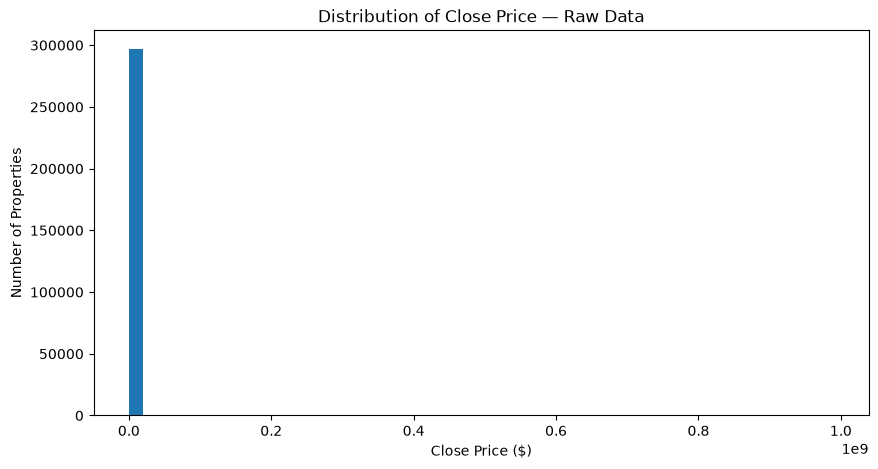

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(df_sfr["ClosePrice"].dropna(), bins=50)

plt.xlabel("Close Price ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price — Raw Data")

plt.show()

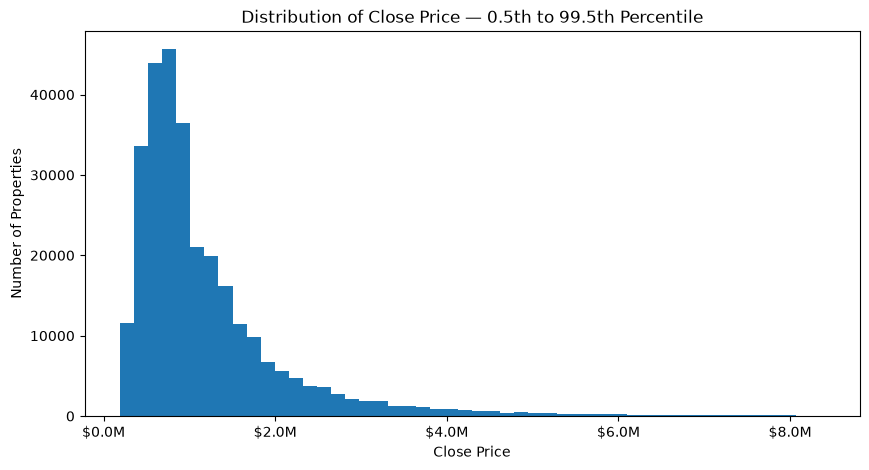

0.5th percentile: $190,000
99.5th percentile: $8,400,000


In [32]:
from matplotlib.ticker import FuncFormatter

price_lower = df_sfr["ClosePrice"].quantile(0.005)
price_upper = df_sfr["ClosePrice"].quantile(0.995)

price_plot = df_sfr[
    df_sfr["ClosePrice"].between(price_lower, price_upper)
]

plt.figure(figsize=(10, 5))
plt.hist(price_plot["ClosePrice"].dropna(), bins=50)

plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price — 0.5th to 99.5th Percentile")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

print(f"0.5th percentile: ${price_lower:,.0f}")
print(f"99.5th percentile: ${price_upper:,.0f}")

**ClosePrice observations:**
- The raw distribution is heavily affected by extreme high-price observations, including values approaching $1 billion.
- After restricting the visualization to the 0.5th–99.5th percentile range, the underlying distribution is much clearer.
- `ClosePrice` remains strongly right-skewed, with most sales concentrated at lower price levels and a long tail of higher-priced homes.
- The percentile restriction is used only for visualization; no observations have been removed from the analysis dataset.

### Missing Values

Check how frequently the key variables are missing before deciding how missing observations should be handled during preprocessing.

In [25]:
missing_summary = pd.DataFrame({
    "MissingCount": df_sfr[numeric_columns].isna().sum(),
    "MissingPercent": df_sfr[numeric_columns].isna().mean() * 100
})

missing_summary.sort_values("MissingPercent", ascending=False)

,MissingCount,MissingPercent
LotSizeSquareFeet,5085,1.71
LivingArea,161,0.05
BathroomsTotalInteger,50,0.02
ClosePrice,2,0.00
BedroomsTotal,0,0.00
